# **Social Network Analysis Project: Group c**
**Chosen Graph:** Avatar (Movie) Co-appearance Network

**Group Members:**
- Carla Di Renzo
- Bianca Marino
- Tommaso Moriondo
- Eleonora Raimondo
- Alessandro Torre

The dataset chosen for this project is the **Avatar movie network**, an **undirected, weighted graph**, in which nodes represent characters and edges represent same-scene co-appearances, weighted by the number of times two characters share a scene. 

Through conducting network analysis on this dataset, we gain insights into the relationships between characters and uncover structural properties of the story that might not be immediately obvious from the raw data alone.

## Dataset Description

| Property | Details |
|----------|---------|
| **Nodes** | Characters in the movie |
| **Edges** | Co-appearance in the same scene between two characters |
| **Weight** | Number of shared scene appearances |
| **Type** | Undirected, Weighted |

*Source: J. Kaminski et al., "Moviegalaxies - Social Networks in Movies." https://doi.org/10.7910/DVN/T4HBA3, Harvard Dataverse, V3 (2018)*


## 1. Data Loading
We load the two CSV files containing the network data: `nodes.csv` (characters) and `edges.csv` (co-appearance links).


In [73]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

In [74]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT/"data"

nodes_path = DATA_DIR/"nodes.csv"
edges_path = DATA_DIR/"edges.csv"

nodes = pd.read_csv(nodes_path)
edges = pd.read_csv(edges_path)


## 2. Data Exploration

### 2.1 Nodes
Analysing the table of nodes to understand how characters are presented.


In [75]:
nodes.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Id        30 non-null     int64
 1   Label     30 non-null     str  
 2   movie_id  30 non-null     int64
dtypes: int64(2), str(1)
memory usage: 852.0 bytes


In [76]:
nodes.head()

,Id,Label,movie_id
0,519631,JAKE,88
1,520100,QUARITCH,88
2,520425,SELFRIDGE,88
3,520314,GRACE,88
4,520156,NORM,88


The nodes table contains **30 characters**, each described by:
- `Id`: unique numeric identifier
- `Label`: character name (JAKE, QUARITCH, GRACE)
- `movie_id`:movie identifier (88 = Avatar)

There are **no missing values**, therefore the data is ready to be used directly. 

### 2.2 Edges
Furthermore, we inspect the edges table to understand how co-appearances are recorded.

In [77]:
edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Source    105 non-null    int64
 1   Target    105 non-null    int64
 2   Type      105 non-null    str  
 3   Id        105 non-null    int64
 4   Label     105 non-null    int64
 5   Weight    105 non-null    int64
 6   movie_id  105 non-null    int64
dtypes: int64(6), str(1)
memory usage: 5.9 KB


In [78]:
edges.head()

,Source,Target,Type,Id,Label,Weight,movie_id
0,519777,519783,Undirected,0,17872,1,88
1,519965,519631,Undirected,1,17876,1,88
2,519965,520084,Undirected,2,17877,1,88
3,519965,520010,Undirected,3,17875,1,88
4,522131,520314,Undirected,4,18043,1,88


The edge table contains **105 co-appearance connections** between characters. 

Key observations:
- All edges are `undirected`: if character A shares a scene with B, the same is true for the opposite (A ⭤ B)
- The `Weight` column counts **how many scenes** two characters shared: a higher weight indicates a stronger relationship
- The `Label` column is a numerical identifier of the edge and can be ignored for analysis

This confirms that we are working with an **undirected, weighted network** of 30 nodes and 105 edges.

# **Week 1**

### 1.1 Graph Building

We construct an undirected weighted graph using NetworkX. 

Each character becomes a **node** and each co-appearance becomes an **edge**, with the **weight** representing the number of shared scenes.


In [79]:
G = nx.Graph() # builds an empty undirected graph

# Add nodes with label attribute
for _, row in nodes.iterrows():
    G.add_node(row['Id'], label=row['Label'])

# Add edges with weight attribute
for _, row in edges.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

### 1.2 Graph Visualization

We visualize the network using a spring layout, where the thickness of the edges reflects the weight, the number of shared scenes between two characters.


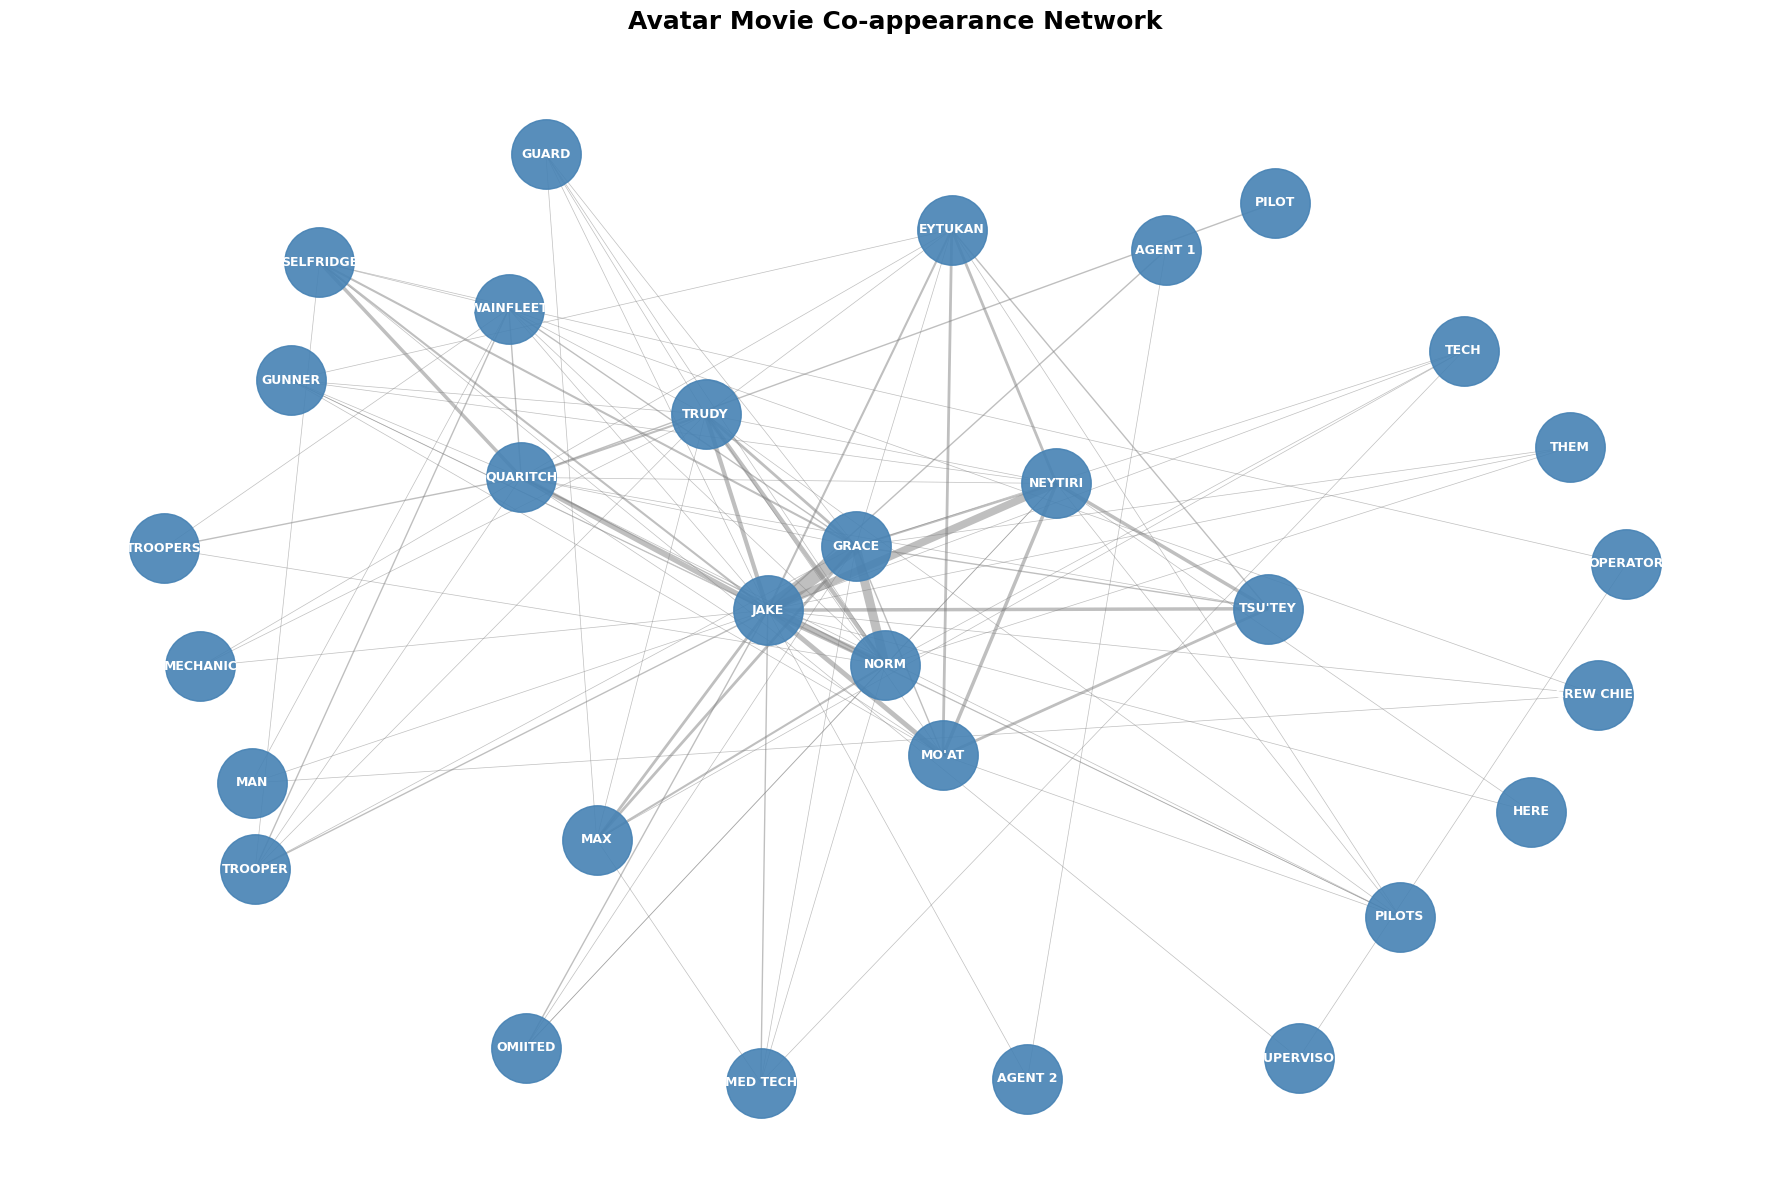

In [80]:
plt.figure(figsize=(18, 12))  # bigger canvas
pos = nx.spring_layout(G, seed=54, k=2.5)  # k spreads nodes further apart
labels = nx.get_node_attributes(G, 'label')
weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='steelblue', alpha=0.9)  # bigger nodes
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, width=[w * 0.5 for w in weights], alpha=0.5, edge_color='gray')

plt.title("Avatar Movie Co-appearance Network", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

### **Graph Interpretation:**

- **JAKE, GRACE, NORM, TRUDY, NEYTIRI and QUARITCH** appear at the center of the network, with numerous connections to other characters, highlighting that they are the protagonists of the story.

- **JAKE** in particular sits at the very centre, with the thickest edges connecting him to NEYTIRI, GRACE and NORM, highlighting how many screen time he shares with them. 

- The **peripheral nodes** (PILOT, HERE, THEM) have very few connections and represent minor or secondary characters who interact only briefly with the main cast.

- The network has a clear **hub-and-spoke structure**: a dense core of main characters surrounded by more loosely connected secondary characters


### 1.3 Basic Network Statistics

We now compute the key structural metrics of the network.

In [81]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes
density = nx.density(G)

print(f"Number of nodes  : {num_nodes}")
print(f"Number of edges  : {num_edges}")
print(f"Average degree   : {avg_degree:.4f}")
print(f"Density          : {density:.4f}")


Number of nodes  : 30
Number of edges  : 105
Average degree   : 7.0000
Density          : 0.2414


### **Interpretation:**

The Avatar cast network consists of **30 nodes** and **105 edges**, with an average degree of **7.0**, meaning that each character shares scenes with 7 others on average.
  
This is a relatively high value for a network of 30 nodes, indicating a well-connected cast in which interactions are spread across many character pairs rather than concentrated on a few.

The network density is **0.2414**, meaning that only about 24% of all possible connections actually exist.
This moderate sparseness is consistent with the plot, as the film is structured around two distinct social worlds.
Between the **military/human group** (Jake, Quaritch, Grace, Norm, Trudy) and the **Na'vi clan** (Neytiri, Mo'at, Tsu'tey), who interact intensely within each group, but only through a few key characters who act as bridges between the groups. 
**Jake**, for example, serves as the main bridge, belonging to both worlds throughout the story.

A fully connected network of 30 nodes would require 435 edges, but we only have 105, which confirms that the interactions between the characters are selective and structured rather than random.

# **Week 2**

### 2.1 Clustering Coefficient


#### Clustering Coefficient of Node $i$

The **local clustering coefficient** of node $i$ is defined as the ratio of pairs of friends of $i$ that are also friends with each other:

$$C(i) := \frac{\text{Number of triangles where } i \text{ participates}}{k_i(k_i - 1)/2}$$

where $k_i$ is the degree of node $i$ and $k_i(k_i-1)/2$ is the number of **wedges** (pairs of friends) around $i$. By convention, $C(i) = 0$ if $i$ has fewer than 2 neighbors.



#### Average Clustering

To compare across graphs, we average the local clustering coefficients over all nodes:

$$\langle C \rangle = \frac{1}{N} \sum_{i \in V} C(i)$$



#### Transitivity

Rather than averaging locally, transitivity counts triangles **globally** and normalises by the total number of connected triples (wedges):

$$T(G) := \frac{3 \times \text{Number of triangles}}{\sum_i \binom{k_i}{2}} = \frac{3 \times \text{Number of triangles}}{\sum_i k_i(k_i-1)/2}$$

The factor of 3 appears because each triangle contains exactly 3 wedges, one centred on each of its nodes, so multiplying by 3 ensures the
numerator and denominator are on the same scale.


In [82]:
def clustering(G): 
    clusters = dict()
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        
        if degree < 2: #need at least 2 neighbors to form a triangle 
            clusters[node] = 0.0
            continue
            
        triangles = sum(1 for i in range(degree) for j in range(i+1, degree) if G.has_edge(neighbors[i], neighbors[j])) 
        local_wages = degree * (degree - 1) / 2 
        
        clusters[node] = triangles / local_wages
        
    return clusters

In [83]:
def average_clustering(G):
    c = clustering(G)
    return sum(c.values()) / len(c)

In [84]:
# My clustering
my_clustering = clustering(G)
my_avg = average_clustering(G)

# NetworkX built-ins
nx_clustering = nx.clustering(G)
nx_avg = nx.average_clustering(G)
nx_transitivity = nx.transitivity(G)

print(f"Custom average clustering   : {my_avg:.6f}")
print(f"NetworkX average clustering : {nx_avg:.6f}")
print(f"NetworkX transitivity       : {nx_transitivity:.6f}")


Custom average clustering   : 0.804295
NetworkX average clustering : 0.804295
NetworkX transitivity       : 0.500928


### **Interpretation:**

- The **average clustering of 0.80** is very high, meaning that 80% of a character's co-stars also act together.
This shows that characters from the same group (like a military team or Na'vi clan) often appear together, forming many small groups.

- **Transitivity (0.50)** is lower because it is a *global* measure that weights nodes by their number of wedges. 

- **Hub characters** like JAKE and GRACE are connected to nodes from different communities that rarely interact with each other directly, so their wedges are less likely to close into triangles pulling the global transitivity down."

- The gap between **average clustering (0.80)** and **transitivity (0.50)** is a signature of a **hub-and-spoke structure**: there are close local groups, but the connections between them lower the overall number of groups.


# **Week 3**

### 3.1 CDF of Node Clustering Coefficients

We use the **Cumulative Distribution Function (CDF)** instead of a histogram to show the distribution of clustering values because clustering is a continuous value. 

This choice helps avoid random bin selections and provides a clearer view of how clustering values are spread out across nodes.


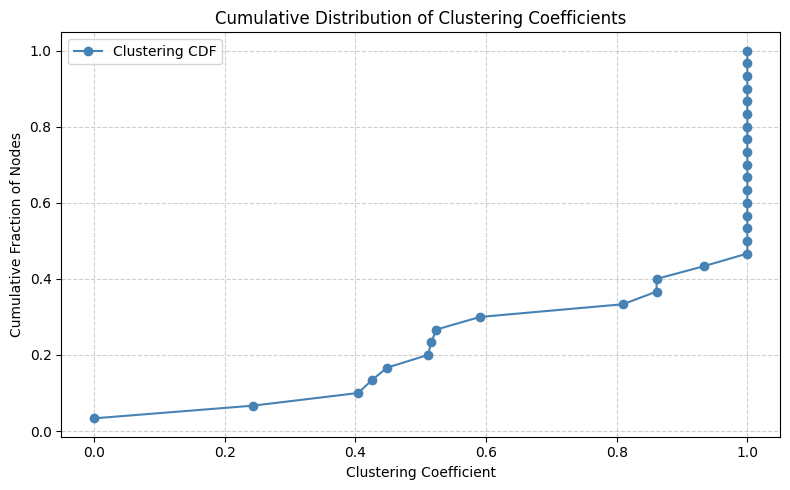

In [85]:
import numpy as np

# Get clustering values sorted
clust_values = sorted(my_clustering.values())
cdf = np.arange(1, len(clust_values) + 1) / len(clust_values)

plt.figure(figsize=(8, 5))
plt.plot(clust_values, cdf, marker='o', color='steelblue', label='Clustering CDF')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Fraction of Nodes')
plt.title('Cumulative Distribution of Clustering Coefficients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### **Graph Interpretation**:

There is a flat region from **0.0 to ~0.38**: roughly 7% of nodes have very low clustering (close to 0). These are minor characters like **OPERATOR** and **SUPERVISOR** who appear briefly alongside main cast members, but whose connections never meet each other, isolated connectors with no triangles
around them.

From **0.38 to 0.85**, the curve rises gradually, capturing intermediate characters, like **TRUDY, NORM, WAINFLEET**, who are partially embedded in groups but also bridge across communities, so not all of their neighbors interact with each other.

There is a significant jump at **clustering = 1.0**, with about 53% of the nodes (16 out of 30) having a clustering coefficient of 1.0. This demonstrates that more than half of the characters are part of tight-knit groups in which everyone shares scenes with everyone else, such as the Na’vi clan, who frequently appear together in the story.

### 3.2 Average Neighbor Clustering

For each node, we compute the **average clustering coefficient of its neighbors**, this tells us whether a character's co-stars tend to be tightly embedded in groups themselves.


In [86]:
def avg_neighbor_clustering(G, clustering_dict):
    result = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        if degree == 0:
            result[node] = 0.0
        else:
            result[node] = np.mean([clustering_dict[n] for n in neighbors])
    return result

neighbor_avg_clust = avg_neighbor_clustering(G, my_clustering)


### 3.3 Comparing the Two Distributions


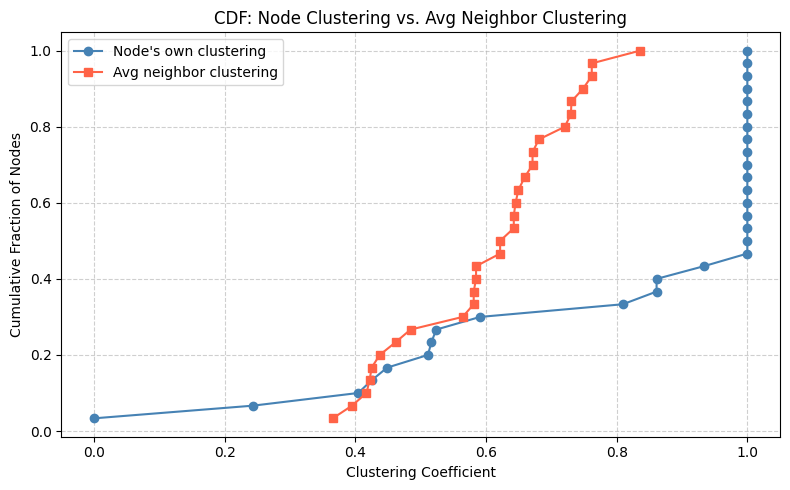

In [87]:
neigh_values = sorted(neighbor_avg_clust.values())
cdf_neigh = np.arange(1, len(neigh_values) + 1) / len(neigh_values)

plt.figure(figsize=(8, 5))
plt.plot(clust_values, cdf, marker='o', color='steelblue', label="Node's own clustering")
plt.plot(neigh_values, cdf_neigh, marker='s', color='tomato', label="Avg neighbor clustering")
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Fraction of Nodes')
plt.title("CDF: Node Clustering vs. Avg Neighbor Clustering")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### **Graph Interpretation**:

The **neighbor clustering curve (red)** shifts to the left of the **node clustering curve (blue)** across almost the entire range, meaning that, on average, a character’s neighbors tend to have lower clustering than the character itself, which is a pattern known as disassortative clustering mixing.

Specifically, the **red curve** reaches **1.0** at a clustering value of **~0.85**, while the **blue curve** reaches **1.0** only at **1.0.** This gap of ~0.15 means that even the most clustered characters (those in compact groups) have neighbors whose average clustering is lower than their own.

There is a turning point around **0.55–0.60**. Below this value, the degree of clustering among neighbors is actually slightly higher than that of the nodes themselves, meaning that hub nodes with a low degree of clustering, such as **JAKE**, are surrounded by more tightly clustered neighbors, that is, the members of the faction to which they are connected. **Above 0.60**, the relationship reverses, as highly clustered peripheral nodes reconnect to less clustered hubs.

This makes intuitive sense in Avatar, where tightly knit groups like the **Na’vi clan** connect to central bridge characters like **JAKE**, who spans multiple worlds and therefore has a lower clustering coefficient than the group members surrounding him. 


In social network terms, your friends social circles tend to be less tight than your own, and the main characters, by spreading their connections across communities, pull their neighbors’ average clustering down.


# **Week 5**

### Choice of Centrality Measures

There is no one clear meaning of “importance” in a network; it varies based on what we want to learn, like how information spreads, how infections move, influence, or how failures happen. So, we need to pick the best ways to measure based on what our network is like. In 

Avatar's co-appearance network, a link between two characters shows that they were in the same scene, so the network shows how close they are and how they interact in the story. Therefore, we focus on:


- **Betweenness centrality**: measures how important a node is in terms of *connecting other nodes*. 
In a co-appearance network, a character with high betweenness acts as a narrative bridge, without them, other characters would never interact. This is particularly important here because the film revolves *around two opposing factions* (human military vs. Na'vi), and we expect a few characters to connect both sides.

- **Closeness centrality**: measures how easily a node can *reach all other nodes*, defined as the **inverse of the average distance** to all others:
$$C^{clo}(i) = \frac{N-1}{\sum_{j \neq i} d(i,j)}$$
 A character with high closeness is very involved in the story and interacts with many others.

We do not use **degree centrality** as it only captures the raw number of connections without accounting for the network's structure, and **decay centrality** as it introduces a free parameter $\delta$ that would require additional justification to set. 

**PageRank** is designed for directed networks and is less natural here since co-appearances are symmetric.


### 5.1 Graph Preprocessing

We work on the **Largest Connected Component (LCC)** to ensure all distance-based metrics are well-defined, and set `inv_weight = 1/weight` as the distance attribute.


In [88]:
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
G_lcc.remove_edges_from(nx.selfloop_edges(G_lcc))

# Add inverse weight as distance attribute
for u, v, d in G_lcc.edges(data=True):
    d['inv_weight'] = 1 / d['weight']

betweenness = nx.betweenness_centrality(G_lcc, weight='inv_weight')
closeness   = nx.closeness_centrality(G_lcc, distance='inv_weight')


### 5.2 Most Central Nodes

In [89]:
df_centrality = pd.DataFrame({
    'Label'      : [G_lcc.nodes[n]['label'] for n in G_lcc.nodes()],
    'Betweenness': [betweenness[n] for n in G_lcc.nodes()],
    'Closeness'  : [closeness[n]   for n in G_lcc.nodes()]
})

df_centrality = df_centrality.sort_values('Betweenness', ascending=False).reset_index(drop=True)
print(df_centrality.to_string(index=False))


     Label  Betweenness  Closeness
      JAKE     0.736658   1.584044
  QUARITCH     0.172824   1.429379
 SELFRIDGE     0.133005   1.168066
     GRACE     0.067529   1.515022
   NEYTIRI     0.011084   1.429883
     TRUDY     0.005337   1.305861
      NORM     0.004721   1.416439
 WAINFLEET     0.002463   0.954434
       MAX     0.000616   1.174600
   EYTUKAN     0.000000   1.098188
     MO'AT     0.000000   1.338314
   TROOPER     0.000000   0.913099
   AGENT 1     0.000000   0.911732
   AGENT 2     0.000000   0.633083
CREW CHIEF     0.000000   0.647901
     GUARD     0.000000   0.634633
    GUNNER     0.000000   0.663652
      HERE     0.000000   0.628613
       MAN     0.000000   0.647901
  MECHANIC     0.000000   0.640676
  MED TECH     0.000000   0.911732
   OMIITED     0.000000   0.897622
  OPERATOR     0.000000   0.559550
     PILOT     0.000000   0.845764
    PILOTS     0.000000   0.663652
SUPERVISOR     0.000000   0.559550
      TECH     0.000000   0.639297
      THEM     0.000

### **Interpretation:**

**Betweenness centrality** highlights characters who act as structural bridges. 

**JAKE** dominates with a score of 0.737, far above everyone else, confirming his unique role as the connector between the human military and the Na'vi world. Without JAKE, the two factions would be almost entirely disconnected. 

**QUARITCH (0.173)** and **SELFRIDGE (0.133)** rank next, as they coordinate the human side and connect peripheral military characters to the core network.

**Closeness centrality** measures how quickly a character can reach everyone else in the network. 

**JAKE (1.584)** again leads, followed closely by **GRACE (1.515)** and **NEYTIRI (1.430)**, all three interact across multiple groups throughout the film. 

Peripheral characters such as **OPERATOR, SUPERVISOR, and GUARD** score below 0.65, as they appear in very few scenes and are structurally distant from the core.

The two metrics tell a consistent story: JAKE is both the most central *bridge* and the most *reachable* character, highlighting his role as the main character who exists between two worlds.

### 5.3 Visualization

The **size** of the nodes shows how much they connect others (bigger = more connections); the **color** of the nodes shows how close they are to all other nodes (greener = closer).


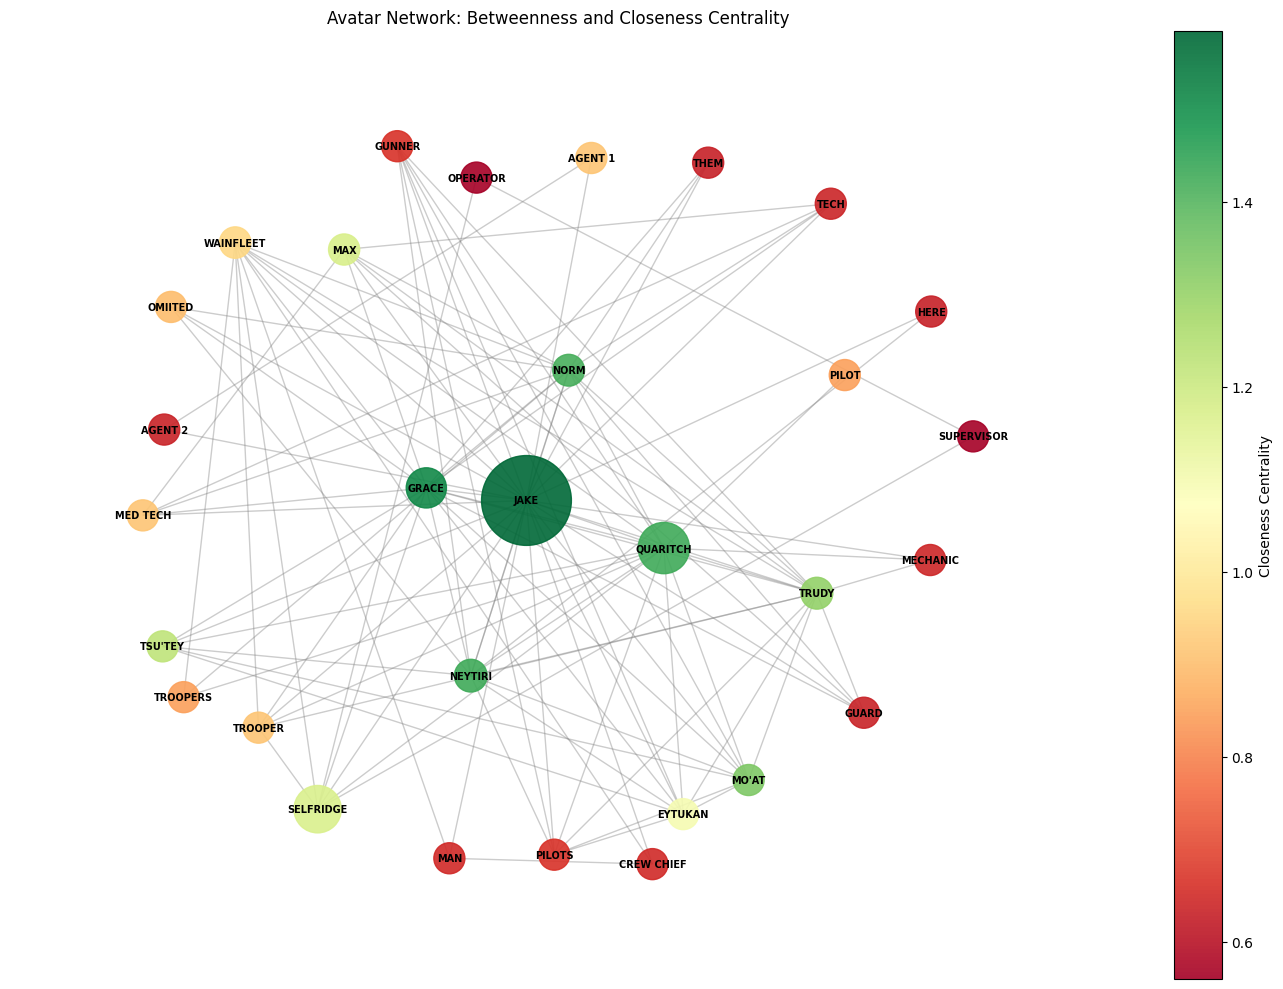

In [90]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_lcc, seed=42, k=3)  # k spreads nodes apart
labels = nx.get_node_attributes(G_lcc, 'label')
node_size  = [betweenness[n] * 5000 + 500 for n in G_lcc.nodes()]  # scale down multiplier
node_color = [closeness[n] for n in G_lcc.nodes()]
nx.draw_networkx_edges(G_lcc, pos, alpha=0.4, edge_color='gray')
nc = nx.draw_networkx_nodes(G_lcc, pos, node_size=node_size, node_color=node_color, cmap=plt.cm.RdYlGn, alpha=0.9)
nx.draw_networkx_labels(G_lcc, pos, labels=labels, font_size=7, font_color='black', font_weight='bold')
plt.colorbar(nc, label='Closeness Centrality')
plt.title("Avatar Network: Betweenness and Closeness Centrality")
plt.axis('off')
plt.margins(0.1)
plt.tight_layout()
plt.show()

### **Graph Interpretation:**
The visualization confirms the quantitative results: 

- **JAKE** (betweenness: 0.737, closeness: 1.584), stands out clearly as the largest and darkest green node, dominating both dimensions of centrality. 

- **GRACE, NORM and NEYTIRI** are also deep green, indicating high closeness centrality. All three are embedded in the dense core of the network and can reach all other characters quickly. However, their smaller size compared to JAKE shows they play a much smaller bridging role between groups.

- **QUARITCH and SELFRIDGE** appear yellow-green with moderate size, they have decent closeness (well connected on the human side) and non-trivial betweenness (they link peripheral military characters to the core), but they are clearly secondary connectors compared to JAKE.

- The cluster of small red nodes at the periphery represents the minor characters who are structurally isolated from the core of the story.


# **Week 6**

### 6.1 Graph Preprocessing

We build an unweighted copy of the LCC and remove all self-loops, as required.


In [91]:
# we build the unweighted copy
G_unw = nx.Graph()
G_unw.add_nodes_from(G_lcc.nodes(data=True))
G_unw.add_edges_from(G_lcc.edges())
G_unw.remove_edges_from(nx.selfloop_edges(G_unw))


### 6.2 Method: Modularity Optimization

**Modularity** evaluates a partition not in absolute terms, but relative to a random baseline: it measures the difference between the actual number of internal links in each community and the expected number under a randomized network. 

A high modularity means the community structure is unlikely to be the result of a random process.

For an undirected, unweighted network, the modularity of a partition is:

$$Q = \frac{1}{L} \sum_{C} \left( L_C - \frac{k_C^2}{4L} \right)$$

where $L$ is the total number of links, $L_C$ is the number of internal links in community $C$, and $k_C$ is the sum of degrees of all nodes in $C$. The term $\frac{k_C^2}{4L}$ represents the expected number of internal links under the configuration model (random baseline).

We use **Newman's greedy algorithm**, which starts from $N$ singleton communities and iteratively merges the pair yielding the highest increase in $Q$, returning the partition with maximum modularity.


In [92]:
from networkx.algorithms.community import greedy_modularity_communities

communities_mod = greedy_modularity_communities(G_unw)
modularity_mod  = nx.community.modularity(G_unw, communities_mod)

print(f"Modularity optimization (communities: {len(communities_mod)}, modularity: {modularity_mod:.4f})")


Modularity optimization (communities: 3, modularity: 0.2675)


Each community has more internal connections than external ones, satisfying the **weak community** condition: the sum of internal degrees exceeds the sum of external degrees. 

The three groups align naturally with the narrative structure of the film.

### 6.3 Method: Label Propagation

**Label propagation** works on the idea that nearby nodes usually belong to the same group. The steps are:

1. Each node starts with a unique label
2. At each step, every node adopts the label of the **majority of its neighbors** (ties broken at random)
3. The process repeats until a stationary state is reached, no node changes its label
4. Communities are groups of nodes sharing the same label in the final state

In [93]:
from networkx.algorithms.community import label_propagation_communities

communities_lp = label_propagation_communities(G_unw)
communities_lp = list(communities_lp)
modularity_lp  = nx.community.modularity(G_unw, communities_lp)

print(f"Label propagation (communities: {len(communities_lp)}, modularity: {modularity_lp:.4f})")


Label propagation (communities: 2, modularity: 0.0183)


This is a known limitation of label propagation: the final partition is **heavily dependent on the random order in which nodes are visited** and on tie-breaking during the sweep. 

In a dense, strongly connected network like this, one main label spreads throughout the entire graph, leading to a simple division with very low modularity.

### 6.4 Community Members


In [94]:
print("\n Modularity Optimization")
for i, comm in enumerate(communities_mod):
    names = [G_unw.nodes[n]['label'] for n in comm]
    print(f"Community {i+1}: {names}")

print("\n Label Propagation")
for i, comm in enumerate(communities_lp):
    names = [G_unw.nodes[n]['label'] for n in comm]
    print(f"Community {i+1}: {names}")



 Modularity Optimization
Community 1: ['GUNNER', "MO'AT", 'QUARITCH', 'PILOT', 'HERE', 'PILOTS', 'NEYTIRI', "TSU'TEY", 'EYTUKAN', 'TRUDY', 'MECHANIC']
Community 2: ['AGENT 1', 'OPERATOR', 'AGENT 2', 'SELFRIDGE', 'WAINFLEET', 'SUPERVISOR', 'JAKE', 'MAN', 'TROOPER', 'CREW CHIEF']
Community 3: ['MAX', 'GRACE', 'TROOPERS', 'OMIITED', 'TECH', 'MED TECH', 'THEM', 'NORM', 'GUARD']

 Label Propagation
Community 1: ['MAX', 'PILOT', 'PILOTS', 'TECH', 'EYTUKAN', 'MAN', 'TROOPER', 'TRUDY', 'CREW CHIEF', 'QUARITCH', 'MED TECH', 'GUARD', 'GUNNER', "MO'AT", 'WAINFLEET', 'TROOPERS', 'JAKE', "TSU'TEY", 'NORM', 'OMIITED', 'MECHANIC', 'AGENT 1', 'THEM', 'AGENT 2', 'SELFRIDGE', 'HERE', 'GRACE', 'NEYTIRI']
Community 2: ['OPERATOR', 'SUPERVISOR']


### 6.5 Discussion: Best Partition
**Modularity optimization is the best choice.** 

With a modularity of 0.2675, it produces a meaningful and interpretable partition: a Na'vi-centered group (Community 1), a human military group (Community 2), and a science/support group around Grace and Norm (Community 3). All consistent with the plot structure of the film.

**Label propagation** collapses almost the entire network into one community (28 nodes), leaving only **OPERATOR** and **SUPERVISOR** isolated, with a near-zero modularity of 0.0183. This is a typical failure case on dense, well-connected graphs.
The algorithm spreads a single label across the whole network, unable to distinguish meaningful subgroups.

We therefore use the modularity optimization partition for the Gephi visualization.

### 6.6 Export for Gephi

In [95]:
# Assign community ID to each node (use the best partition)
best_communities = communities_mod  

for i, comm in enumerate(best_communities):
    for node in comm:
        G_unw.nodes[node]['community'] = i

# Export as GEXF for Gephi
nx.write_gexf(G_unw, "avatar_communities.gexf")


### 6.7 Gephi Visualization

The graph below is exported from Gephi Lite using the modularity optimization partition. 
Node **color** encodes community membership; node **size** encodes degree.

In [96]:
import os
for root, dirs, files in os.walk(Path.cwd().parent):
    for f in files:
        if 'gephi' in f.lower():
            P = os.path.join(root, f)

In [97]:
import base64
from IPython.display import HTML

try: 
    with open("gephi_avatar.png", "rb") as f:
        data = base64.b64encode(f.read()).decode()
    HTML(f'<img src="data:image/png;base64,{data}" width="900"/>')
except FileNotFoundError:
    print('graph image not found')

### **Graph Analysis**
**Community Colors (Modularity Optimization, Q = 0.2675):**
- Orange: Human military core: JAKE, SELFRIDGE, WAINFLEET, MAN, TROOPER, CREW CHIEF, AGENT 1, AGENT 2, OPERATOR, SUPERVISOR
- Blue: Na'vi & conflict group: QUARITCH, NEYTIRI, TSU'TEY, EYTUKAN, MO'AT, TRUDY, GUNNER, PILOTS, PILOT, MECHANIC, HERE
- Green: Science/support team: GRACE, NORM, MAX, GUARD, TROOPERS, MED TECH, TECH, THEM, OMIITED


# **Week 7**

### 7.1 Graph Preprocessing

We reuse `G_unw`: already undirected, unweighted, loop-free, and restricted to the largest connected component.

In [98]:
missing_links = [(u, v) for u, v in nx.non_edges(G_unw)]

### 7.2 Choice of Indices

**Link prediction** is the task of estimating the likelihood of a link existing between two unconnected nodes. 
The **link completion** interpretation: given the Avatar co-appearance network as a snapshot, we ask which pairs of characters are structurally likely to have shared a scene that was not recorded.

Most link prediction methods are grounded in **homophily** the tendency of similar nodes to connect. We use the **similarity-based approach**, which consists of three steps:
1. Define and compute similarity indices for all unconnected pairs $U = P - E$, where $P$ is the set of all possible links.
2. Compute a score quantifying the probability of connection.
3. Rank node pairs by score and predict the top ones.

We focus on **local topological indices**, which rely only on the immediate neighborhood of two nodes. We compute:

- **Common Neighbors (CN)**: counts the number of nodes that are neighbors of both $x$ and $y$:
$$CN(x, y) = |\Gamma(x) \cap \Gamma(y)|$$
Based on the notion of **transitivity**, if A shares scenes with B and C, then B and C are likely to share a scene too. However, CN is **not normalized**: two pairs with the same number of common neighbors score equally, even if one pair has a much larger total neighborhood. This is why indices like JI and AA were introduced as refinements.

- **Adamic-Adar Index (AA)**: a weighted refinement of CN where less-connected common neighbors are assigned more weight:
$$AA(x, y) = \sum_{z \in \Gamma(x) \cap \Gamma(y)} \frac{1}{\log |\Gamma(z)|}$$
The intuition is that a rare mutual connection (low-degree shared neighbor) is more informative than a hub that everyone is connected to. 
A character like JAKE appears as a common neighbor of almost every pair but this tells us little. AA down-weights these hub contributions automatically.

We chose AA over the other available indices because:
- **Jaccard Index (JI)** $= \frac{|\Gamma(x) \cap \Gamma(y)|}{|\Gamma(x) \cup \Gamma(y)|}$ normalizes by total neighbors and loses raw count information, which is relevant in a small network like ours.
- **Preferential Attachment (PA)** $= |\Gamma(x)| \times |\Gamma(y)|$ uses no intersection at all and mainly reconstructs links to hubs, less meaningful here.
- **Resource Allocation (RA)** $= \sum_{z \in \Gamma(x) \cap \Gamma(y)} \frac{1}{|\Gamma(z)|}$ penalizes hubs even more aggressively than AA; it performs better on networks with large average degree, but our network has average degree 7, a regime where AA and RA perform comparably and AA is more standard.

In [99]:
def link_prediction_scores(G, missing_links):
    # CN: Common Neighbors (manual)
    def common_neighbors(G, u, v):
        return len(list(nx.common_neighbors(G, u, v)))
    
    # AA: Adamic-Adar (built-in)
    aa_dict = {(u, v): score for u, v, score in nx.adamic_adar_index(G, missing_links)}
    
    rows = []
    for u, v in missing_links:
        label_u = G.nodes[u]['label']
        label_v = G.nodes[v]['label']
        cn = common_neighbors(G, u, v)
        aa = aa_dict[(u, v)]
        rows.append({'Pair': f"{label_u} ↔ {label_v}", 'CN': cn, 'AA': aa})
    
    return pd.DataFrame(rows)

df_lp = link_prediction_scores(G_unw, missing_links)
print(df_lp.sort_values(['CN', 'AA'], ascending=[False, False]).head(10).to_string(index=False))

               Pair  CN       AA
     PILOTS ↔ GRACE   6 2.362933
     GUNNER ↔ GRACE   6 2.362933
    TRUDY ↔ TSU'TEY   6 2.336966
  TRUDY ↔ SELFRIDGE   5 2.016702
   PILOTS ↔ TSU'TEY   5 1.984010
   GUNNER ↔ TSU'TEY   5 1.984010
     TROOPER ↔ NORM   5 1.837515
     EYTUKAN ↔ NORM   5 1.805650
       MO'AT ↔ NORM   5 1.805650
WAINFLEET ↔ NEYTIRI   5 1.793092


### **Interpretation**
The table ranks missing links by CN first, then AA as a tiebreaker. 
The top pairs, PILOTS ↔ GRACE, GUNNER ↔ GRACE, and TRUDY ↔ TSU'TEYall, all share 6 common neighbors, the maximum observed, making them the strongest candidates for missing links by transitivity. 

When CN ties, AA breaks the order: PILOTS ↔ GRACE and GUNNER ↔ GRACE score AA = 2.363 vs TRUDY ↔ TSU'TEY at 2.337, meaning their shared neighbors are slightly lower-degree and thus more informative. 

The remaining pairs all have CN = 5, with AA scores ranging from 2.017 down to 1.793, reflecting decreasing structural evidence for a missing link

### 7.3 Combined Score

When using more than one index, we need a proper **aggregation function**. 

The arithmetic sum can be used, but **only after rescaling each index between 0 and 1**, otherwise, indices on different scales would not contribute equally to the final score.

We apply **min-max rescaling** to both CN and AA:

$$\tilde{s}(x,y) = \frac{s(x,y) - s_{\min}}{s_{\max} - s_{\min}}$$

Then the combined score is the sum of the two rescaled indices:

$$\text{Combined}(x, y) = \widetilde{CN}(x,y) + \widetilde{AA}(x,y)$$

This ensures both indices contribute equally to the final ranking, regardless of their original scale (CN is an integer count, AA is a log-weighted float).

In [100]:
def link_prediction_scores(G, missing_links):
    def common_neighbors(G, u, v):
        return len(list(nx.common_neighbors(G, u, v)))
    
    aa_dict = {(u, v): score for u, v, score in nx.adamic_adar_index(G, missing_links)}
    
    rows = []
    for u, v in missing_links:
        label_u = G.nodes[u]['label']
        label_v = G.nodes[v]['label']
        cn = common_neighbors(G, u, v)
        aa = aa_dict[(u, v)]
        rows.append({'Pair': f"{label_u} ↔ {label_v}", 'CN': cn, 'AA': aa})
    
    df = pd.DataFrame(rows)
    
    # Rescale to [0,1] before combining
    df['CN_scaled'] = (df['CN'] - df['CN'].min()) / (df['CN'].max() - df['CN'].min())
    df['AA_scaled'] = (df['AA'] - df['AA'].min()) / (df['AA'].max() - df['AA'].min())
    df['Combined']  = (df['CN_scaled'] + df['AA_scaled']) / 2
    
    return df[['Pair', 'CN', 'AA', 'Combined']]

df_lp = link_prediction_scores(G_unw, missing_links)


### 7.4 Top Missing Links

In [101]:
for score, label in [('CN', 'Common Neighbors'), ('AA', 'Adamic-Adar'), ('Combined', 'Combined Score')]:
    print(f"\nTop 10 by {label}")
    print("-" * 45)
    
    sort_cols = ['CN', 'AA'] if score == 'CN' else [score]
    top = df_lp.sort_values(sort_cols, ascending=False).head(10)[['Pair', score]]
    print(top.to_string(index=False))


Top 10 by Common Neighbors
---------------------------------------------
               Pair  CN
     PILOTS ↔ GRACE   6
     GUNNER ↔ GRACE   6
    TRUDY ↔ TSU'TEY   6
  TRUDY ↔ SELFRIDGE   5
   PILOTS ↔ TSU'TEY   5
   GUNNER ↔ TSU'TEY   5
     TROOPER ↔ NORM   5
     EYTUKAN ↔ NORM   5
       MO'AT ↔ NORM   5
WAINFLEET ↔ NEYTIRI   5

Top 10 by Adamic-Adar
---------------------------------------------
               Pair       AA
     GUNNER ↔ GRACE 2.362933
     PILOTS ↔ GRACE 2.362933
    TRUDY ↔ TSU'TEY 2.336966
  TRUDY ↔ SELFRIDGE 2.016702
   GUNNER ↔ TSU'TEY 1.984010
   PILOTS ↔ TSU'TEY 1.984010
     TROOPER ↔ NORM 1.837515
     EYTUKAN ↔ NORM 1.805650
       MO'AT ↔ NORM 1.805650
WAINFLEET ↔ NEYTIRI 1.793092

Top 10 by Combined Score
---------------------------------------------
               Pair  Combined
     GUNNER ↔ GRACE  1.000000
     PILOTS ↔ GRACE  1.000000
    TRUDY ↔ TSU'TEY  0.994505
  TRUDY ↔ SELFRIDGE  0.843404
   GUNNER ↔ TSU'TEY  0.836486
   PILOTS ↔ TSU'TEY  0

### **Interpretation**

The top 10 missing links show a clear pattern: all pairs have 5-6 common neighbors, which keeps them close even though they never appear together. 

**GUNNER ↔ GRACE** and **PILOTS ↔ GRACE** have the highest **Adamic-Adar score (AA = 2.363)** even though they tie on **Common Neighbors (CN = 6)** with **TRUDY ↔ TSU'TEY**. This is because AA penalizes high-degree hubs like JAKE, their 6 shared neighbors are lower-degree characters, which the index rewards with higher weight.

**TRUDY ↔ TSU'TEY (CN = 6, AA = 2.337)** is the most interesting prediction: TRUDY is the human pilot who joins the Na'vi, and TSU'TEY is the Na'vi warrior. They share 6 key characters from both factions but never appear in the same scene, yet the network identifies them as a structurally likely missing link.

**TRUDY ↔ SELFRIDGE (CN = 5, AA = 2.017)** stands out among the 5-CN group because it has the highest AA score in that tier, meaning its shared neighbors are particularly low-degree and thus carry more predictive weight.

**GUNNER ↔ TSU'TEY** and **PILOTS ↔ TSU'TEY** mirror each other exactly (CN = 5, AA = 1.984, Combined = 0.836), reflecting the symmetric role these two minor military characters play in the network. Finally, **TROOPER ↔ NORM**, **MO'AT ↔ NORM**, and **EYTUKAN ↔ NORM** all cluster around **NORM**, who bridges the human science team and the Na'vi world, making him a natural shared neighbor for characters from both sides and explaining why this group appears together at the bottom of the top 10.

# **Week 9**

### 9.1 Theoretical Background

The goal of random graph models is to create networks that look like real social networks. 
There are three main features of social networks:

- **Small-world property**: diameter is small
- **High clustering coefficient**: friends of friends tend to be friends
- **Heterogeneity of degrees**: there is a large spread of different degrees

We compare the Avatar network against the most fundamental random graph model: the **Erdős–Rényi (ER) model**, used here as a structural baseline.

### 9.2 The Erdős–Rényi Model

The ER model $G(n, p)$ is defined as follows:

- Start with $n$ nodes and zero links. For each pair of nodes $i$ and $j$, generate a random number $r$ uniformly between 0 and 1. 
- If $r \leq p$, nodes $i$ and $j$ get connected; otherwise they remain disconnected.


The probability of observing a specific graph with $l$ edges present out of $\frac{n(n-1)}{2}$ possible edges is:

$$P(G) = p^l \cdot (1-p)^{\frac{n(n-1)}{2} - l}$$

The key theoretical properties of $G(n,p)$ are:

- **Expected number of links**: $\langle L \rangle = p \cdot \frac{n(n-1)}{2}$
- **Expected density**: $\langle D \rangle = p$
- **Expected average degree**: $\langle \text{deg} \rangle = p(n-1)$
- **Expected average clustering**: by independence of edges, $\langle C \rangle = p$
- **Degree distribution**: follows a **Binomial distribution**:

$$P(\deg(i) = k) = \binom{n-1}{k} p^k (1-p)^{n-1-k}$$

The ER model is the natural baseline for our comparison: it preserves the size and density of the original network while assuming **no structure**, where edges are placed purely at random. 
Any deviation from ER reveals meaningful structural properties of the Avatar network.

We set:
- $n = 30$ (same number of nodes as Avatar)
- $p = 0.2414$ (equal to the Avatar network density), which guarantees an expected average degree of $p(n-1) = 0.2414 \times 29 \approx 7.0$

In [102]:
n = G.number_of_nodes()
p = nx.density(G)

# Generate ER graph with same n and p
ER = nx.erdos_renyi_graph(n=n, p=p, seed=42)

print(f"ER (Nodes): {ER.number_of_nodes()}, Edges: {ER.number_of_edges()}")
print(f"ER (Avg degree): {sum(dict(ER.degree()).values()) / n:.4f}")
print(f"ER (Density): {nx.density(ER):.4f}")

ER (Nodes): 30, Edges: 109
ER (Avg degree): 7.2667
ER (Density): 0.2506


### 9.3 Structural Comparison

We compute four structural metrics on both networks. 

For ER, we work on its **Largest Connected Component (LCC)**, as $G(n,p)$ is not guaranteed to be connected, the graph connects fully only when $p \gg \frac{\ln n}{n}$. 

In [103]:
# Avatar (on unweighted LCC for fair comparison)
avatar_clustering   = nx.average_clustering(G_unw, count_zeros=True)
avatar_transitivity = nx.transitivity(G_unw)
avatar_diameter     = nx.diameter(G_unw)
avatar_avg_path     = nx.average_shortest_path_length(G_unw)

# ER (work on LCC in case it's disconnected)
ER_lcc = ER.subgraph(max(nx.connected_components(ER), key=len)).copy()
er_clustering   = nx.average_clustering(ER_lcc, count_zeros=True)
er_transitivity = nx.transitivity(ER_lcc)
er_diameter     = nx.diameter(ER_lcc)
er_avg_path     = nx.average_shortest_path_length(ER_lcc)

df_comparison = pd.DataFrame({
    'Property'  : ['Avg Clustering', 'Transitivity', 'Diameter', 'Avg Path Length'],
    'Avatar'    : [avatar_clustering, avatar_transitivity, avatar_diameter, avatar_avg_path],
    'Erdős–Rényi': [er_clustering,   er_transitivity,     er_diameter,     er_avg_path]
}).set_index('Property')

df_comparison

,Avatar,Erdős–Rényi
Property,,
Avg Clustering,0.804295,0.264101
Transitivity,0.500928,0.247012
Diameter,3.000000,3.000000
Avg Path Length,1.891954,1.843678


### 9.4 Degree Distribution CDF

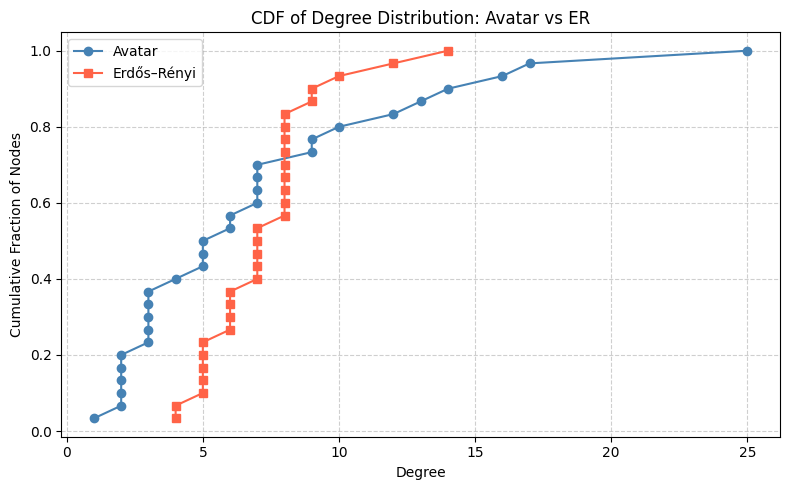

In [104]:
def get_degree_cdf(G):
    degrees = sorted([d for _, d in G.degree()])
    cdf = np.arange(1, len(degrees) + 1) / len(degrees)
    return degrees, cdf

deg_avatar, cdf_avatar = get_degree_cdf(G_unw)
deg_er, cdf_er         = get_degree_cdf(ER_lcc)

plt.figure(figsize=(8, 5))
plt.plot(deg_avatar, cdf_avatar, marker='o', color='steelblue', label='Avatar')
plt.plot(deg_er, cdf_er, marker='s', color='tomato', label='Erdős–Rényi')
plt.xlabel('Degree')
plt.ylabel('Cumulative Fraction of Nodes')
plt.title('CDF of Degree Distribution: Avatar vs ER')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### **Graph Interpretation**

The ER model matches Avatar in nodes and average degree by design. But the two networks are very different in other ways: 

- **Average clustering:** Avatar (0.80) is about three times higher than ER (0.26). The ER model suggests that clustering should be close to $p$ for large $n$. Avatar’s higher value reflects its group structure, in which characters from the same group (such as clans or teams) form many closed triangles that random connections cannot form. 

- **Transitivity:** Avatar (0.50) is double that of ER (0.25), showing many closed triangles due to the film’s group structure. ER cannot create much transitivity because its connections are random. 

- **Diameter & Average Path Length:** Both networks have the same diameter (3) and similar average path lengths (~1.89 vs ~1.84). Even with higher clustering, Avatar is still a small world, with characters less than 2 steps apart on average. This matches the small-world property mentioned in the slides. 

- **Degree distribution:** The Avatar CDF goes up to degree 25 (JAKE), showing a varied distribution with a few main characters, a key feature of real social networks. The ER CDF is more even and focuses on degrees 5–13, matching its theoretical Binomial distribution, which has low variation around the average. 

Overall, the ER comparison shows that the Avatar network **is not random.** Its high clustering and community structure come from the film’s story, where characters interact in specific groups, not randomly. The only thing the ER model gets right is the small diameter, showing that small-world paths can happen even without a clear structure.


# **Week 10**

### 10.1 Background Contagion models show how things spread in a network, like diseases, information, or ideas. 

There are three types of models: 

- **Innovation models (Deterministic)**: These models activate agents based on fixed rules. Once activated, they stay active forever. 

- **Innovation models (Stochastic)**: These models activate agents based on chance meetings. Once activated, they also stay active forever. 

- **Epidemic models (Stochastic)**: In these models, agents can change between different states multiple times, and changes happen randomly. 

We focus on the **SIS (Susceptible-Infected-Susceptible)** model from the third type. Unlike other models where activation is permanent, the SIS model lets nodes switch between infected and susceptible states. This is useful for modeling repeated influences. 

### 10.2 SIS Model Definition 

The SIS model works like this: 
1. Choose some nodes to start as infected; the rest are susceptible. 
2. In each round, visit all nodes: 
    - If a node is **S (Susceptible)**: It can become **I (Infected)** if it has infected neighbors, with a chance of $\beta$. 
    - If a node is **I (Infected)**: It can become **S (Susceptible)** again with a chance of $\mu$. 

The two main factors are: 
- $\beta$ (infection rate): chance of getting infected from each infected neighbor. 
- $\mu$ (recovery rate): chance of becoming susceptible again. 

The chance that a susceptible node with $k_I$ infected neighbors gets infected is: $$P(\text{infection}) = 1 - (1 - \beta)^{k_I(t)}$$ 

This shows how each infected neighbor tries to infect independently. 

### 10.3 Basic Reproduction Number $R_0$ 

A key number for epidemic models is the **basic reproduction number** $R_0$. 


It tells us if the epidemic will grow or fade away. In the SIS model, the epidemic grows if new infections are more than recoveries: 

- Recoveries per step: $I_{rec} = \mu \cdot I$ 

- New infections per step: $I_{sec} \approx \beta \cdot \langle k \rangle \cdot I$ 

The epidemic spreads if $I_{sec} > I_{rec}$, which means: $$R_0 = \frac{\beta \cdot \langle k \rangle}{\mu} > 1$$ 

For our network, with $\beta = 0.3$, $\mu = 0.1$, and $\langle k \rangle = 7$: $$R_0 = \frac{0.3 \times 7}{0.1} = 21 \gg 1$$ 

This means the infection is likely to stay and reach a stable state where a certain number of nodes are always infected. 

The steady state $(S^*, I^*)$ is where the infection rate stops changing, leading to many nodes being infected. 

We use **synchronous update**: all nodes are checked at once based on their current state, and then all changes happen together.

In [105]:
import random

def sis_model(G, beta, delta, initial_infected, steps=50):
    """
    SIS model on graph G.
    beta  : infection probability per infected neighbor
    delta : recovery probability
    initial_infected : list of initially infected nodes
    Returns list of (step, num_infected) tuples and final state dict
    """
    state = {node: 'S' for node in G.nodes()}
    for node in initial_infected:
        state[node] = 'I'
    
    history = []
    
    for step in range(steps):
        new_state = state.copy()
        for node in G.nodes():
            if state[node] == 'S':
                infected_neighbors = sum(1 for n in G.neighbors(node) if state[n] == 'I')
                prob_infection = 1 - (1 - beta) ** infected_neighbors
                if random.random() < prob_infection:
                    new_state[node] = 'I'
            elif state[node] == 'I':
                if random.random() < delta:
                    new_state[node] = 'S'
        state = new_state
        history.append((step, sum(1 for s in state.values() if s == 'I')))
    
    return history, state

### 10.4 Scenario 1: Effect of Initial Origin (β=0.3, δ=0.1)

We seed the infection from four characters with structurally different roles in the network, to test the slide claim that **hubs and core nodes are better influencers** than peripheral ones:

- **JAKE**: highest betweenness centrality (0.737), bridge across all communities
- **NEYTIRI**: central in the Na'vi community
- **QUARITCH**: central in the military community
- **SUPERVISOR**: peripheral node with degree 2, far from the core

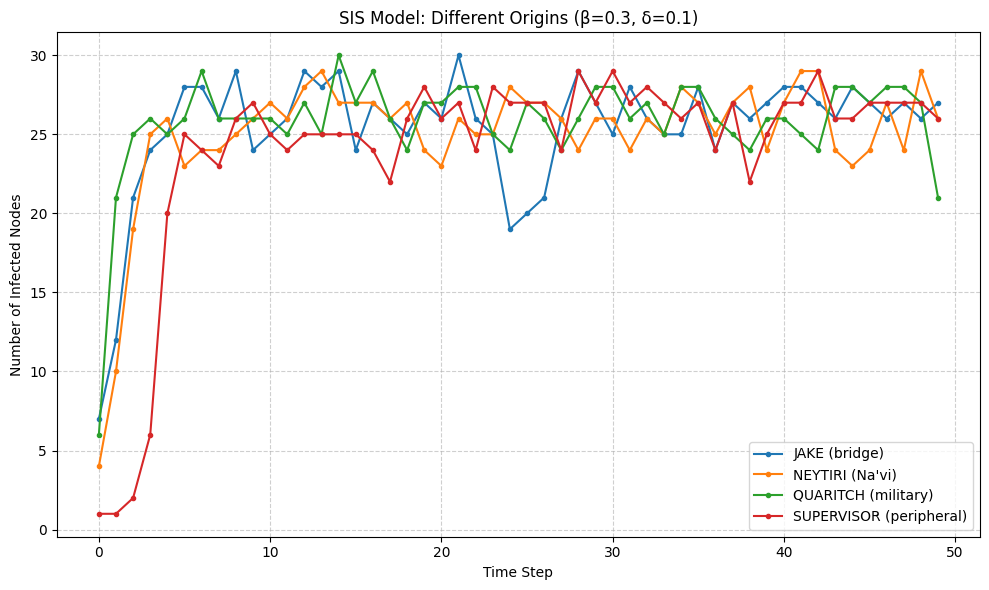

In [106]:
random.seed(54)

# Get node IDs by label
label_to_node = {G_unw.nodes[n]['label']: n for n in G_unw.nodes()}

beta, delta = 0.3, 0.1
steps = 50

scenarios = {
    'JAKE (bridge)'     : [label_to_node['JAKE']],
    'NEYTIRI (Na\'vi)'  : [label_to_node['NEYTIRI']],
    'QUARITCH (military)': [label_to_node['QUARITCH']],
    'SUPERVISOR (peripheral)': [label_to_node['SUPERVISOR']],
}

plt.figure(figsize=(10, 6))
for label, seed in scenarios.items():
    history, _ = sis_model(G_unw, beta, delta, seed, steps)
    steps_list, infected = zip(*history)
    plt.plot(steps_list, infected, marker='o', markersize=3, label=label)

plt.xlabel('Time Step')
plt.ylabel('Number of Infected Nodes')
plt.title(f'SIS Model: Different Origins (β={beta}, δ={delta})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Graph Interpretation**
All origins except SUPERVISOR reach the endemic level (about 25–29 nodes) within 5 steps. SUPERVISOR behaves differently as a peripheral node with degree 2. It starts the spread extremely slowly, infecting only 1 node at step 0. However, it eventually converges to the same endemic equilibrium by about step 10.

This confirms the theoretical result: with $R_0 = 21 \gg 1$, the infection always reaches the same endemic state regardless of where it starts; the initial seed controls speed, not final size. 

Hubs and core nodes are better influencers because they spread things faster, not because they affect the final result.

From a network perspective, **JAKE's dominance** in speed is explained by his betweenness centrality of **0.737**; he simultaneously bridges the Na'vi, military, and science communities, so a single infection starting at JAKE propagates to all three groups within the first few steps. 

NEYTIRI and QUARITCH, each central within one community, are slightly slower because they must first cross a community boundary before reaching the rest of the network.

### 10.5 Scenario 2: Effect of Infection Rate β (origin: JAKE, δ=0.1)

We fix the origin (JAKE) and the recovery rate ($\mu = 0.1$) and vary $\beta \in \{0.1, 0.2, 0.3, 0.5\}$. This tests how the contagion rate affects both the speed of spreading and the endemic level and where the epidemic threshold $R_0 = 1$ falls in practice.

For each value:
- $\beta = 0.1$: $R_0 = 7$ → epidemic spreads but recovery partially contains it
- $\beta = 0.2$: $R_0 = 14$ → strong spreading
- $\beta = 0.3$: $R_0 = 21$ → very strong spreading
- $\beta = 0.5$: $R_0 = 35$ → near-saturating spreading

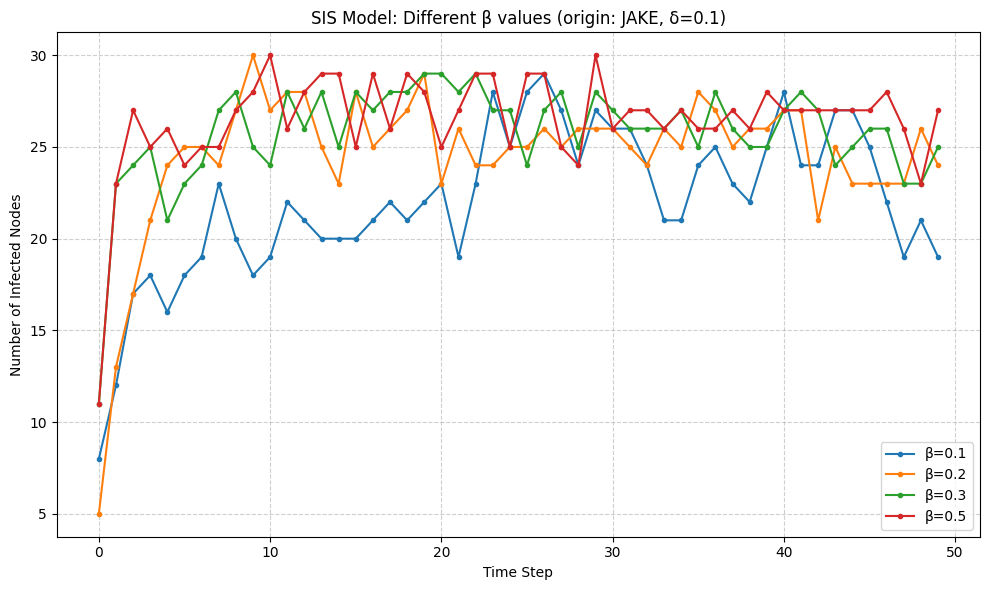

In [107]:
random.seed(42)

delta = 0.1
betas = [0.1, 0.2, 0.3, 0.5]
seed  = [label_to_node['JAKE']]

plt.figure(figsize=(10, 6))
for beta in betas:
    history, _ = sis_model(G_unw, beta, delta, seed, steps=50)
    steps_list, infected = zip(*history)
    plt.plot(steps_list, infected, marker='o', markersize=3, label=f'β={beta}')

plt.xlabel('Time Step')
plt.ylabel('Number of Infected Nodes')
plt.title(f'SIS Model: Different β values (origin: JAKE, δ={delta})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Graph Interpretation**

We fix the origin (JAKE) and vary $\beta \in \{0.1, 0.2, 0.3, 0.5\}$, giving basic reproduction numbers of $R_0 \in \{7, 14, 21, 35\}$ respectively.

While all four values of $\beta$ meet the condition $R_0 > 1$, there is a noticeable **practical difference** between $\beta = 0.1$ and the other values. When $\beta = 0.1$, the infection stabilizes at around 19 to 23 nodes, significantly lower than the 25 to 29 nodes seen with the higher $\beta$ values. This indicates a **structural epidemic threshold** in this particular network: the high clustering within the Avatar network ($C = 0.80$) restricts the infection to certain communities, and a lower $\beta$ is insufficient to effectively bridge the gaps between them.

Only above $\beta \approx 0.2$ does the infection reliably saturate the full network.

The three higher values ($\beta \in \{0.2, 0.3, 0.5\}$) all converge to the same endemic level, with higher $\beta$ reaching it faster. This is consistent with the SIS theoretical result: once $R_0 \gg 1$, the **endemic equilibrium is determined by the ratio $\beta / \mu$**, not by $\beta$ alone and for these three cases the ratio is large enough that the network is nearly fully saturated in all scenarios.

### 10.6 Scenario 3:  Effect of Outbreak Size (β=0.3, δ=0.1)

The slides note that when choosing several initial active agents, one needs to **take into account communities**. We test this directly by seeding one, three, or five initial nodes selecting seeds that either concentrate in one community or span all three:

- **Small**: 1 node → JAKE only (one community entry point)
- **Medium**: 3 nodes → one per community (JAKE, NEYTIRI, QUARITCH)
- **Large**: 5 nodes → all three communities seeded (JAKE, NEYTIRI, QUARITCH, GRACE, EYTUKAN)

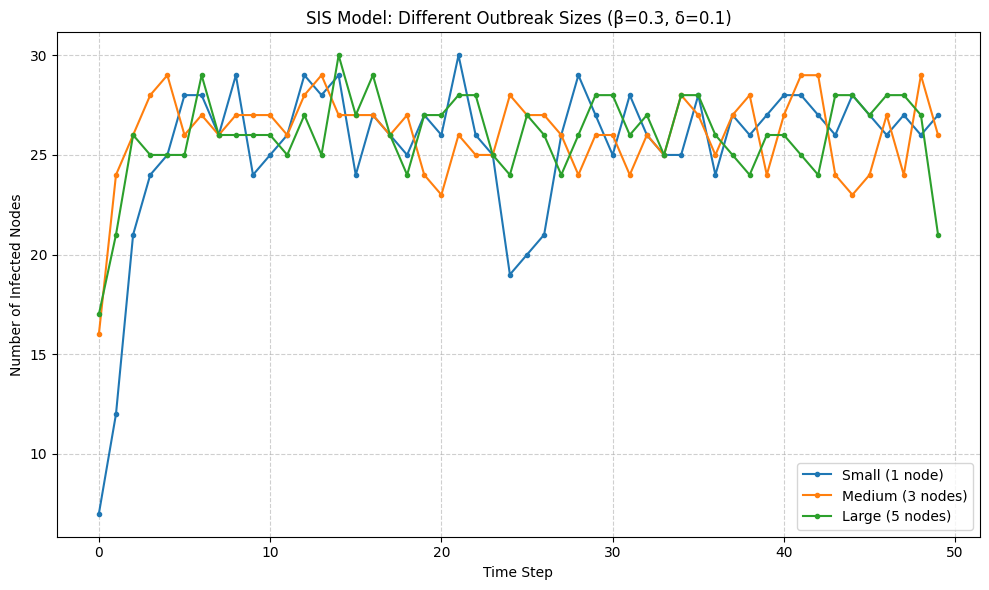

In [108]:
random.seed(54)

beta, delta = 0.3, 0.1

# Small: 1 node, Medium: 3 nodes (one per community), Large: 5 nodes
small  = [label_to_node['JAKE']]
medium = [label_to_node['JAKE'], label_to_node['NEYTIRI'], label_to_node['QUARITCH']]
large  = [label_to_node['JAKE'], label_to_node['NEYTIRI'], label_to_node['QUARITCH'],
          label_to_node['GRACE'], label_to_node['EYTUKAN']]

plt.figure(figsize=(10, 6))
for label, seed in [('Small (1 node)', small), ('Medium (3 nodes)', medium), ('Large (5 nodes)', large)]:
    history, _ = sis_model(G_unw, beta, delta, seed, steps=50)
    steps_list, infected = zip(*history)
    plt.plot(steps_list, infected, marker='o', markersize=3, label=label)

plt.xlabel('Time Step')
plt.ylabel('Number of Infected Nodes')
plt.title(f'SIS Model: Different Outbreak Sizes (β={beta}, δ={delta})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Graph Interpretation**

To initiate the infection, we selected either 1, 3, or 5 initially infected nodes. These nodes were chosen to either focus on one community or to span all three communities identified in Week 6.

All three outbreak sizes converge to the same endemic equilibrium (~25–28 nodes), confirming once again that with $R_0 = 21$, the **final state is independent of the initial outbreak size**. 

However, larger and more distributed outbreaks reach the endemic level noticeably faster: the medium seed (one node per community) converges faster than the small seed, and the large seed is even quicker in the first 3 steps.

This directly validates the slide recommendation: **when choosing several initial infected agents, one needs to take into account communities**. In the Avatar network, the three-community layout serves as a key barrier to rapid contagion. When starting with just one infected node, it must first overcome a barrier to enter other communities before spreading widely. However, by seeding one node in each community, this barrier is completely removed. This approach allows the infection to spread within all three groups simultaneously right from the start.